# Position Sizing and MAE/MFE Analysis
**Docker image**: `ml4t`

## Purpose
Connect path-risk theory to trade construction by implementing fixed-fractional
and volatility-based position sizing, then calibrating stop and target levels
from the realized excursion profile of the underlying price series.

## Learning Objectives
After completing this notebook, you will be able to:
- Implement fixed-fractional and volatility-based position sizing with concentration caps
- Analyze MAE/MFE distributions to calibrate stop-loss levels from trade outcomes
- Compare full-exit and scale-out policies on a common entry set
- Translate horizon-conditional excursion percentiles into pre-trade TP/SL levels

## Book reference
Chapter 19 §19.4 (drawdowns and path risk) and §19.7 (adaptive risk controls);
Figure 19.4 (stop-loss exit distribution) and Figure 19.8 (MAE/MFE calibration).

## Prerequisites
Complete [`02_exit_strategies`](02_exit_strategies.ipynb) first for the stop-rule
taxonomy this notebook calibrates.

## Setup

In [1]:
"""Position Sizing and MAE/MFE Analysis — implement sizing methods and calibrate stops via trade excursion analysis."""

import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_etfs
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI
SEED = 42

In [3]:
np.random.seed(SEED)
OUTPUT_DIR = get_output_dir(19, "position_sizing_mae_mfe")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
set_global_seeds(SEED)

## 1. Data Preparation

In [5]:
# Load from canonical ETF universe
SYMBOLS = ["SPY", "QQQ", "IWM", "TLT"]
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"

etf_data = load_etfs()

# Filter to symbols and date range
etf_filtered = (
    etf_data.filter(pl.col("symbol").is_in(SYMBOLS))
    .filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime())
    .filter(pl.col("timestamp") <= pl.lit(END_DATE).str.to_datetime())
    .sort(["symbol", "timestamp"])
)

# Pivot each price column to wide format
close_prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .to_pandas()
    .set_index("timestamp")
)
high_prices = (
    etf_filtered.select(["timestamp", "symbol", "high"])
    .pivot(on="symbol", index="timestamp", values="high")
    .to_pandas()
    .set_index("timestamp")
)
low_prices = (
    etf_filtered.select(["timestamp", "symbol", "low"])
    .pivot(on="symbol", index="timestamp", values="low")
    .to_pandas()
    .set_index("timestamp")
)

In [6]:
# Ensure datetime index and forward fill
for df in [close_prices, high_prices, low_prices]:
    df.index = pd.to_datetime(df.index)

close_prices = close_prices.ffill().dropna()
high_prices = high_prices.ffill().dropna()
low_prices = low_prices.ffill().dropna()

print(f"Loaded {len(close_prices):,} daily bars from canonical data")

Loaded 1,509 daily bars from canonical data


**Interpretation**: The sample keeps the notebook tied to liquid ETFs with long
histories, so the MAE/MFE examples reflect diversified risk assets rather than a
single idiosyncratic name.

In [7]:
# Calculate volatility for each asset
returns = close_prices.pct_change()
volatility = returns.rolling(20).std() * np.sqrt(252)

print("\nAnnualized Volatility (Recent):")
print(volatility.iloc[-1].round(3))


Annualized Volatility (Recent):
IWM    0.235
QQQ    0.115
SPY    0.095
TLT    0.187
Name: 2023-12-29 00:00:00, dtype: float64


**Interpretation**: The recent volatility spread sets up the sizing problem.
TLT typically carries a different risk budget from equity ETFs, so a fixed share
count would misstate risk even before we calibrate stops.

## 2. Fixed Fractional Position Sizing

Risk a fixed percentage of portfolio per trade. The share count is the
risk budget divided by the per-share risk (the entry-to-stop distance):

$$\text{shares} = \frac{V \cdot r}{\lvert P_{\text{entry}} - P_{\text{stop}} \rvert},
  \qquad \text{risk budget } = V \cdot r,$$

where $V$ is portfolio value and $r$ is the risk-per-trade fraction.

The configuration object isolates the two risk-budget choices for fixed-fractional
sizing: how much capital to risk and how much concentration to allow.

In [8]:
@dataclass
class FixedFractionalConfig:
    """Fixed fractional position sizing configuration."""

    risk_per_trade: float = 0.01  # 1% risk per trade
    max_position_pct: float = 0.25  # Max 25% in any position

The sizing function converts the stop distance into shares and enforces the
concentration cap so that wide stops do not create oversized bets.

In [9]:
def calculate_fixed_fractional_size(
    portfolio_value: float,
    entry_price: float,
    stop_price: float,
    config: FixedFractionalConfig,
) -> dict:
    """Calculate position size using the fixed-fractional method.

    Shares = (portfolio_value * risk_per_trade) / |entry - stop|, capped at
    max_position_pct of the portfolio.
    """
    risk_amount = portfolio_value * config.risk_per_trade
    risk_per_share = abs(entry_price - stop_price)

    if risk_per_share <= 0:
        return {"shares": 0, "position_value": 0, "position_pct": 0}

    # Raw position size
    shares = risk_amount / risk_per_share
    position_value = shares * entry_price
    position_pct = position_value / portfolio_value

    # Cap at max position
    if position_pct > config.max_position_pct:
        position_pct = config.max_position_pct
        position_value = portfolio_value * position_pct
        shares = position_value / entry_price

    return {
        "shares": int(shares),
        "position_value": shares * entry_price,
        "position_pct": position_pct,
        "risk_amount": risk_amount,
        "risk_per_share": risk_per_share,
    }

In [10]:
# Example: Fixed fractional sizing
portfolio = 100_000
entry = 450.0  # SPY entry
stop_levels = [445.0, 440.0, 435.0, 430.0]  # Different stop distances

print("Fixed Fractional Position Sizing (1% Risk)")
print("=" * 60)
print(f"Portfolio: ${portfolio:,.0f}, Entry: ${entry:.2f}\n")

for stop in stop_levels:
    config = FixedFractionalConfig(risk_per_trade=0.01)
    result = calculate_fixed_fractional_size(portfolio, entry, stop, config)

    stop_pct = (entry - stop) / entry * 100
    print(f"Stop: ${stop:.2f} ({stop_pct:.1f}% below entry)")
    print(f"  Shares: {result['shares']:,}")
    print(f"  Position: ${result['position_value']:,.0f} ({result['position_pct']:.1%})")
    print(f"  Risk: ${result['risk_amount']:,.0f}")
    print()

Fixed Fractional Position Sizing (1% Risk)
Portfolio: $100,000, Entry: $450.00

Stop: $445.00 (1.1% below entry)
  Shares: 55
  Position: $25,000 (25.0%)
  Risk: $1,000

Stop: $440.00 (2.2% below entry)
  Shares: 55
  Position: $25,000 (25.0%)
  Risk: $1,000

Stop: $435.00 (3.3% below entry)
  Shares: 55
  Position: $25,000 (25.0%)
  Risk: $1,000

Stop: $430.00 (4.4% below entry)
  Shares: 50
  Position: $22,500 (22.5%)
  Risk: $1,000



**Interpretation**: A tighter stop allows more shares for the same dollar risk,
but the concentration cap quickly binds. That is the practical lesson of fixed
fractional sizing: the stop distance and the position cap must be designed together.

## 3. Volatility-Based Position Sizing

Adjust position size inversely to asset volatility.

**Logic**: More volatile assets → smaller positions (equal risk contribution)

This configuration translates risk targeting into simple upper and lower bounds
on the final weight.

In [11]:
@dataclass
class VolatilityBasedConfig:
    """Volatility-based position sizing configuration."""

    target_volatility: float = 0.10  # Target 10% portfolio volatility
    max_position_pct: float = 0.30  # Max 30% in any position
    min_position_pct: float = 0.02  # Min 2% in any position

The volatility-based rule scales the weight inversely with realized volatility
and then clips the result to the allowed range.

In [12]:
def calculate_volatility_based_size(
    asset_volatility: float,
    config: VolatilityBasedConfig,
) -> float:
    """
    Calculate position size based on asset volatility.

    Position Weight = Target Vol / Asset Vol
    """
    if asset_volatility <= 0:
        return 0

    # Raw weight
    weight = config.target_volatility / asset_volatility

    # Apply constraints
    weight = min(weight, config.max_position_pct)
    weight = max(weight, config.min_position_pct)

    return weight

In [13]:
# Example: Volatility-based sizing across assets. Target vol is below the lowest
# realized vol so that the inverse-vol rule produces a differentiated weight per
# asset before any cap binds.
config = VolatilityBasedConfig(target_volatility=0.04, max_position_pct=0.40)

print("Volatility-Based Position Sizing")
print("=" * 60)
print(f"Target Portfolio Volatility: {config.target_volatility:.0%}\n")

for symbol in SYMBOLS:
    vol = volatility[symbol].iloc[-1]
    weight = calculate_volatility_based_size(vol, config)

    print(f"{symbol}:")
    print(f"  Volatility: {vol:.1%}")
    print(f"  Position Weight: {weight:.1%}")
    print()

Volatility-Based Position Sizing
Target Portfolio Volatility: 4%

SPY:
  Volatility: 9.5%
  Position Weight: 40.0%

QQQ:
  Volatility: 11.5%
  Position Weight: 34.6%

IWM:
  Volatility: 23.5%
  Position Weight: 17.0%

TLT:
  Volatility: 18.7%
  Position Weight: 21.3%



**Interpretation**: Weight scales inversely with realized volatility — the
lowest-vol asset receives the largest allocation, and the highest-vol asset the
smallest. The cap binds only when an asset's volatility falls below
target_vol / max_position_pct, which is the threshold separating the
risk-parity regime from the concentration-limited regime.

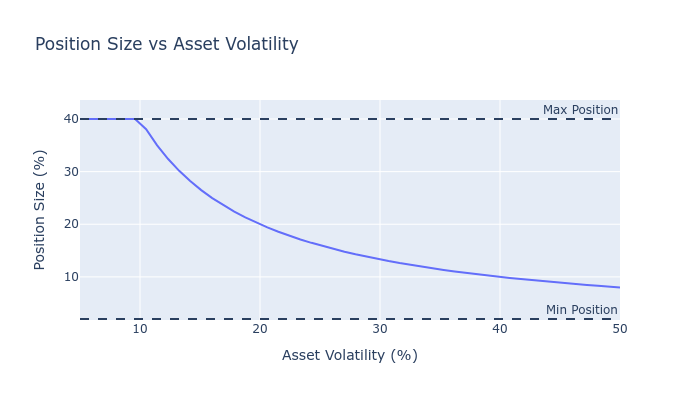

In [14]:
# Visualize how position size varies with volatility
vol_range = np.linspace(0.05, 0.50, 50)
weights = [calculate_volatility_based_size(v, config) for v in vol_range]

fig = go.Figure()
fig.add_trace(
    go.Scatter(x=vol_range * 100, y=np.array(weights) * 100, mode="lines", line=dict(width=2))
)

fig.add_hline(y=config.max_position_pct * 100, line_dash="dash", annotation_text="Max Position")
fig.add_hline(y=config.min_position_pct * 100, line_dash="dash", annotation_text="Min Position")

fig.update_layout(
    title="Position Size vs Asset Volatility",
    xaxis_title="Asset Volatility (%)",
    yaxis_title="Position Size (%)",
    height=400,
)
fig.show()

**Interpretation**: The curve is steep at low volatility and then flattens once
the cap binds. In practice, that means volatility targeting is most sensitive in
the middle of the risk spectrum rather than at the extremes.

## 4. Kelly Criterion (Cross-Reference)

Kelly sizing is covered in Chapter 17 (`kelly_criterion.ipynb`), where it
integrates with portfolio construction. Here we focus on volatility-based
and MAE/MFE methods specific to risk management.

**Key insight**: Kelly optimizes geometric growth but requires accurate
estimates of win rate and payoff ratio. In practice, use fractional Kelly
(½ or ¼) to account for estimation error. See Chapter 17 for implementation.

## 5. Partial Exits / Scale Out

Exit positions in tranches to balance profit-taking and trend-following.

**Example Strategy**:
- Exit 1/3 at first target (lock in profits)
- Exit 1/3 at second target (capture more upside)
- Trail stop on remaining 1/3 (let winners run)

Scale-out logic needs a configuration for the profit targets before we simulate
how the remaining position evolves over time.

In [15]:
@dataclass
class ScaleOutConfig:
    """Scale out (partial exit) configuration."""

    tranches: list[tuple[float, float]]  # (profit_target, exit_fraction)
    # Example: [(0.02, 0.33), (0.04, 0.33), (0.08, 0.34)]

This helper keeps the scale-out simulator compact by recording each tranche exit
in a consistent structure.

In [16]:
def _append_exit(
    exits: list[dict],
    day: int,
    price: float,
    fraction: float,
    exit_type: str,
    pnl: float,
    target: float | None = None,
) -> None:
    record = {
        "day": day,
        "price": price,
        "fraction": fraction,
        "type": exit_type,
        "pnl": pnl,
    }
    if target is not None:
        record["target"] = target
    exits.append(record)

This helper applies the tranche targets once price has moved in our favor.

In [17]:
def apply_scale_out_targets(
    config: ScaleOutConfig,
    current_return: float,
    current_price: float,
    day: int,
    remaining_position: float,
    total_return: float,
    exits: list[dict],
    executed_targets: set[int],
) -> tuple[float, float]:
    # Each tranche fires at most once: skip any tranche index already in
    # executed_targets so a target that stays in-the-money on later bars fires
    # only on its first crossing, instead of re-firing every bar and draining
    # the position.
    for tranche_idx, (target_return, exit_fraction) in enumerate(config.tranches):
        if (
            tranche_idx in executed_targets
            or current_return < target_return
            or remaining_position <= 0
        ):
            continue
        actual_exit = min(exit_fraction, remaining_position)
        pnl = current_return * actual_exit
        total_return += pnl
        _append_exit(
            exits, day, current_price, actual_exit, "take_profit", pnl, target=target_return
        )
        remaining_position -= actual_exit
        executed_targets.add(tranche_idx)
    return remaining_position, total_return

The simulator applies the stop first, then profit targets, and finally closes any
remaining position at the holding-period boundary.

In [18]:
def simulate_scale_out(
    prices: np.ndarray,
    entry_idx: int,
    entry_price: float,
    config: ScaleOutConfig,
    stop_loss_pct: float = 0.02,
    max_holding_days: int = 30,
) -> dict:
    """Simulate a partial-exit policy with stop-loss protection."""
    remaining_position = 1.0
    total_return = 0.0
    exits = []
    executed_targets: set[int] = set()
    stop_price = entry_price * (1 - stop_loss_pct)
    final_idx = min(entry_idx + max_holding_days, len(prices) - 1)

    for i in range(entry_idx + 1, final_idx + 1):
        current_price = prices[i]
        if current_price <= stop_price:
            pnl = (current_price / entry_price - 1) * remaining_position
            total_return += pnl
            _append_exit(exits, i - entry_idx, current_price, remaining_position, "stop_loss", pnl)
            remaining_position = 0
            break

        prev_remaining = remaining_position
        remaining_position, total_return = apply_scale_out_targets(
            config,
            current_price / entry_price - 1,
            current_price,
            i - entry_idx,
            remaining_position,
            total_return,
            exits,
            executed_targets,
        )
        if remaining_position < prev_remaining:
            stop_price = max(stop_price, entry_price)

    if remaining_position > 0:
        final_price = prices[final_idx]
        pnl = (final_price / entry_price - 1) * remaining_position
        total_return += pnl
        _append_exit(exits, final_idx - entry_idx, final_price, remaining_position, "timeout", pnl)

    return {"total_return": total_return, "exits": exits, "n_exits": len(exits)}

In [19]:
# Compare full exit vs scale out
spy_prices = close_prices["SPY"].values

# Generate sample entries
entry_indices = np.sort(np.random.choice(range(50, len(spy_prices) - 50), size=100, replace=False))

# Full exit strategy
full_exit_returns = []
for entry_idx in entry_indices:
    entry_price = spy_prices[entry_idx]
    # Simple: exit at 3% profit or 2% loss
    result = simulate_scale_out(
        spy_prices,
        entry_idx,
        entry_price,
        ScaleOutConfig(tranches=[(0.03, 1.0)]),  # Single exit at 3%
        stop_loss_pct=0.02,
    )
    full_exit_returns.append(result["total_return"])

# Scale out strategy
scale_out_config = ScaleOutConfig(
    tranches=[
        (0.02, 0.33),  # 1/3 at 2%
        (0.04, 0.33),  # 1/3 at 4%
        (0.08, 0.34),  # 1/3 at 8%
    ]
)

scale_out_returns = []
for entry_idx in entry_indices:
    entry_price = spy_prices[entry_idx]
    result = simulate_scale_out(
        spy_prices, entry_idx, entry_price, scale_out_config, stop_loss_pct=0.02
    )
    scale_out_returns.append(result["total_return"])

In [20]:
print("Full Exit vs Scale Out Comparison")
print("=" * 60)

print("\nFull Exit (3% target):")
print(f"  Mean Return: {np.mean(full_exit_returns) * 100:+.2f}%")
print(f"  Std Return:  {np.std(full_exit_returns) * 100:.2f}%")
print(
    f"  Win Rate:    {sum(1 for r in full_exit_returns if r > 0) / len(full_exit_returns) * 100:.1f}%"
)

print("\nScale Out (2%/4%/8% targets):")
print(f"  Mean Return: {np.mean(scale_out_returns) * 100:+.2f}%")
print(f"  Std Return:  {np.std(scale_out_returns) * 100:.2f}%")
print(
    f"  Win Rate:    {sum(1 for r in scale_out_returns if r > 0) / len(scale_out_returns) * 100:.1f}%"
)

Full Exit vs Scale Out Comparison

Full Exit (3% target):
  Mean Return: +0.64%
  Std Return:  3.15%
  Win Rate:    58.0%

Scale Out (2%/4%/8% targets):
  Mean Return: +0.44%
  Std Return:  3.13%
  Win Rate:    54.0%


**Interpretation**: In the conventional account, scaling out trades right-tail
upside for a smoother distribution. On this SPY dataset the numbers above show
the trade-off differently — scale-out gives up upside (mean ≈ 0.44% vs 0.64%) at
essentially the same dispersion (std ≈ 3.13% vs 3.15%) and at a lower win rate
(54.0% vs 58.0%); the smoother-equity-curve story does not generalize to every
entry set, and the policy should be calibrated against the trade ledger, not
assumed.

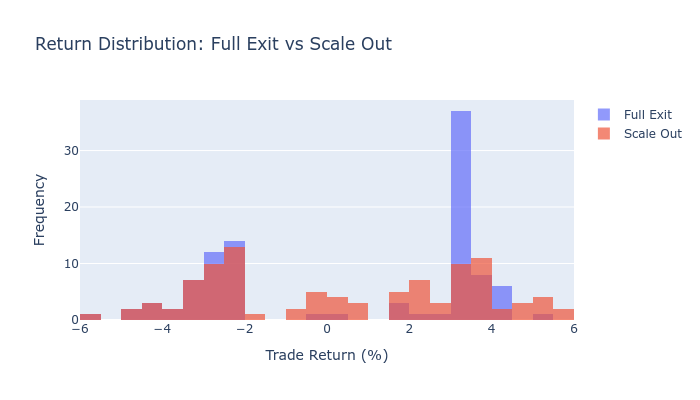

In [21]:
# Visualize return distributions
fig = go.Figure()

fig.add_trace(
    go.Histogram(x=np.array(full_exit_returns) * 100, name="Full Exit", opacity=0.7, nbinsx=30)
)

fig.add_trace(
    go.Histogram(x=np.array(scale_out_returns) * 100, name="Scale Out", opacity=0.7, nbinsx=30)
)

fig.update_layout(
    title="Return Distribution: Full Exit vs Scale Out",
    xaxis_title="Trade Return (%)",
    yaxis_title="Frequency",
    barmode="overlay",
    height=400,
)
fig.show()

**Interpretation**: The histogram makes the trade-off visible. Full exits leave
more mass in the high-return tail; scaling out shifts trades toward modest wins
(mean return ≈ 0.44% vs 0.64% for full exit) at essentially unchanged dispersion
(std ≈ 3.13% vs 3.15%) — and on this dataset the scale-out win rate is actually
lower than full exit (54.0% vs 58.0%), the opposite of the textbook story.

## 6. MAE/MFE Analysis

**MAE (Maximum Adverse Excursion)**: Largest drawdown during a trade
**MFE (Maximum Favorable Excursion)**: Largest gain during a trade

MAE/MFE analysis helps determine optimal stop loss and take profit levels.

In [22]:
def calculate_mae_mfe(
    prices: np.ndarray,
    lows: np.ndarray,
    highs: np.ndarray,
    entry_idx: int,
    exit_idx: int,
    entry_price: float,
) -> dict:
    """
    Calculate MAE and MFE for a trade.

    MAE: Maximum adverse excursion (worst drawdown during trade)
    MFE: Maximum favorable excursion (best gain during trade)
    """
    if exit_idx <= entry_idx:
        return {"mae": 0, "mfe": 0, "mae_pct": 0, "mfe_pct": 0}

    # Use highs/lows for accurate MAE/MFE
    trade_lows = lows[entry_idx : exit_idx + 1]
    trade_highs = highs[entry_idx : exit_idx + 1]

    lowest_price = trade_lows.min()
    highest_price = trade_highs.max()

    mae = (lowest_price - entry_price) / entry_price  # Will be negative
    mfe = (highest_price - entry_price) / entry_price  # Will be positive

    return {
        "mae": mae,
        "mfe": mfe,
        "mae_pct": mae * 100,
        "mfe_pct": mfe * 100,
        "lowest_price": lowest_price,
        "highest_price": highest_price,
    }

In [23]:
# Calculate MAE/MFE for sample trades
spy_lows = low_prices["SPY"].values
spy_highs = high_prices["SPY"].values

mae_mfe_data = []
holding_period = 20  # Fixed 20-day holding for analysis

for entry_idx in entry_indices:
    entry_price = spy_prices[entry_idx]
    exit_idx = min(entry_idx + holding_period, len(spy_prices) - 1)
    exit_price = spy_prices[exit_idx]

    result = calculate_mae_mfe(spy_prices, spy_lows, spy_highs, entry_idx, exit_idx, entry_price)

    trade_return = (exit_price / entry_price - 1) * 100

    mae_mfe_data.append(
        {
            "entry_idx": entry_idx,
            "mae_pct": result["mae_pct"],
            "mfe_pct": result["mfe_pct"],
            "trade_return": trade_return,
            "is_winner": trade_return > 0,
        }
    )

mae_mfe_df = pd.DataFrame(mae_mfe_data)

# Persist MAE/MFE trade-level data for the figure-19.8 publication script (left panel).
pl.from_pandas(mae_mfe_df).write_parquet(OUTPUT_DIR / "mae_mfe_trades.parquet")

In [24]:
print("MAE/MFE Summary")
print("=" * 60)

print(f"\nAll Trades (n={len(mae_mfe_df)}):")
print(f"  Avg MAE: {mae_mfe_df['mae_pct'].mean():.2f}%")
print(f"  Avg MFE: {mae_mfe_df['mfe_pct'].mean():.2f}%")

winners = mae_mfe_df[mae_mfe_df["is_winner"]]
losers = mae_mfe_df[~mae_mfe_df["is_winner"]]

print(f"\nWinners (n={len(winners)}):")
print(f"  Avg MAE: {winners['mae_pct'].mean():.2f}%")
print(f"  Avg MFE: {winners['mfe_pct'].mean():.2f}%")
print(f"  Avg Return: {winners['trade_return'].mean():.2f}%")

print(f"\nLosers (n={len(losers)}):")
print(f"  Avg MAE: {losers['mae_pct'].mean():.2f}%")
print(f"  Avg MFE: {losers['mfe_pct'].mean():.2f}%")
print(f"  Avg Return: {losers['trade_return'].mean():.2f}%")

MAE/MFE Summary

All Trades (n=100):
  Avg MAE: -4.18%
  Avg MFE: 3.56%

Winners (n=69):
  Avg MAE: -2.23%
  Avg MFE: 4.06%
  Avg Return: 3.02%

Losers (n=31):
  Avg MAE: -8.50%
  Avg MFE: 2.44%
  Avg Return: -5.93%


**Interpretation**: Winners and losers separate quickly in excursion space. Trades
that finish positive tend to recover before drawing down deeply, while losers show
larger adverse moves with little offsetting upside.

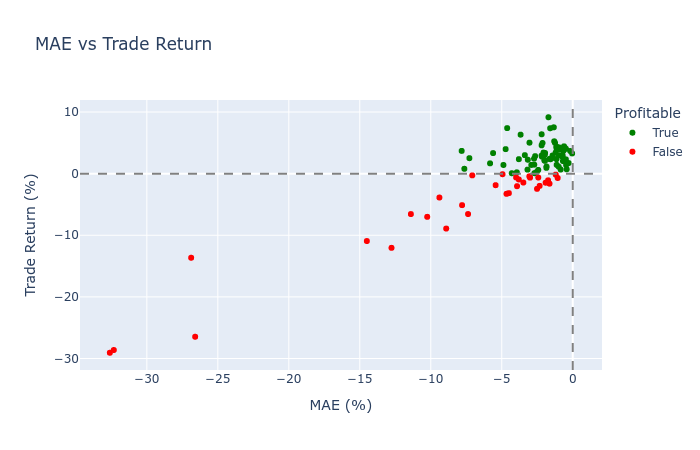

In [25]:
# MAE vs Trade Return scatter
fig = px.scatter(
    mae_mfe_df,
    x="mae_pct",
    y="trade_return",
    color="is_winner",
    color_discrete_map={True: "green", False: "red"},
    title="MAE vs Trade Return",
    labels={"mae_pct": "MAE (%)", "trade_return": "Trade Return (%)", "is_winner": "Profitable"},
)

# Add reference lines
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.add_vline(x=0, line_dash="dash", line_color="gray")

fig.update_layout(height=450)
fig.show()

**Interpretation**: The MAE scatter identifies the stop zone where negative-return
trades cluster. If many winners survive beyond that zone, the stop is too tight.

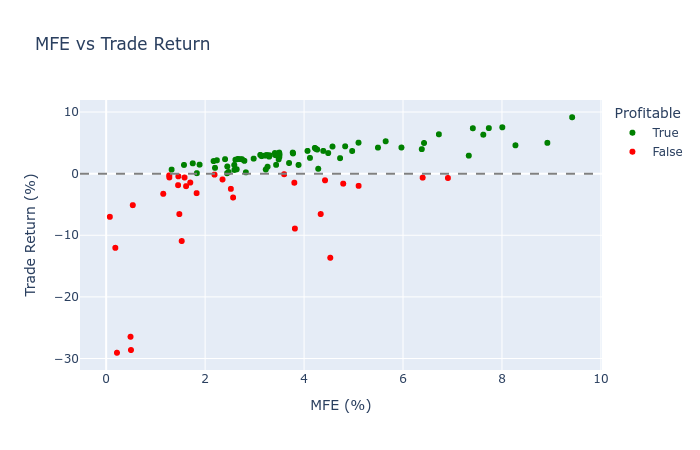

In [26]:
# MFE vs Trade Return scatter
fig = px.scatter(
    mae_mfe_df,
    x="mfe_pct",
    y="trade_return",
    color="is_winner",
    color_discrete_map={True: "green", False: "red"},
    title="MFE vs Trade Return",
    labels={"mfe_pct": "MFE (%)", "trade_return": "Trade Return (%)", "is_winner": "Profitable"},
)

fig.add_hline(y=0, line_dash="dash", line_color="gray")

fig.update_layout(height=450)
fig.show()

**Interpretation**: The MFE scatter shows how much upside winning trades reach
before exit. That helps separate realistic take-profit targets from aspirational ones.

### 6.1 Optimal Stop Loss from MAE

Find the stop level that maximizes the difference between:
- Losers stopped out (avoiding further loss)
- Winners stopped out (premature exit)

In [27]:
def analyze_stop_levels(mae_mfe_df: pd.DataFrame, stop_levels: np.ndarray) -> pd.DataFrame:
    """
    Analyze how different stop levels affect winners and losers.

    For each stop level, calculate:
    - % of losers that would have been stopped (good)
    - % of winners that would have been stopped (bad)
    - Net benefit = losers_stopped - winners_stopped
    """
    results = []

    for stop in stop_levels:
        # Stop is negative (e.g., -2% = stop if drops 2%)
        stopped_losers = ((mae_mfe_df["mae_pct"] <= stop) & (~mae_mfe_df["is_winner"])).sum()
        stopped_winners = ((mae_mfe_df["mae_pct"] <= stop) & (mae_mfe_df["is_winner"])).sum()

        total_losers = (~mae_mfe_df["is_winner"]).sum()
        total_winners = mae_mfe_df["is_winner"].sum()

        pct_losers_stopped = stopped_losers / total_losers if total_losers > 0 else 0
        pct_winners_stopped = stopped_winners / total_winners if total_winners > 0 else 0

        results.append(
            {
                "stop_level": stop,
                "losers_stopped_pct": pct_losers_stopped * 100,
                "winners_stopped_pct": pct_winners_stopped * 100,
                "net_benefit": (pct_losers_stopped - pct_winners_stopped) * 100,
            }
        )

    return pd.DataFrame(results)

In [28]:
# Analyze different stop levels
stop_levels = np.linspace(-5, -0.5, 20)  # -5% to -0.5%
stop_analysis = analyze_stop_levels(mae_mfe_df, stop_levels)
stop_analysis.round(2)

# Persist stop-level tradeoff curve for the figure-19.8 publication script (right panel).
pl.from_pandas(stop_analysis).write_parquet(OUTPUT_DIR / "stop_calibration_tradeoff.parquet")

**Interpretation**: The stop table quantifies the whipsaw trade-off
directly. Tighter stops catch more losers early but also stop out more
eventual winners; wider stops reduce whipsaws but let more losing trades
keep running before the stop binds.

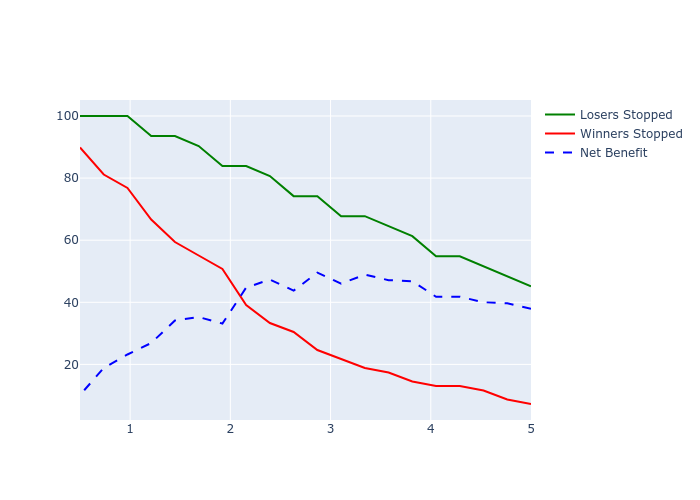

In [29]:
# Visualize stop level tradeoff
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=-stop_analysis["stop_level"],
        y=stop_analysis["losers_stopped_pct"],
        name="Losers Stopped",
        line=dict(color="green"),
    )
)

fig.add_trace(
    go.Scatter(
        x=-stop_analysis["stop_level"],
        y=stop_analysis["winners_stopped_pct"],
        name="Winners Stopped",
        line=dict(color="red"),
    )
)

fig.add_trace(
    go.Scatter(
        x=-stop_analysis["stop_level"],
        y=stop_analysis["net_benefit"],
        name="Net Benefit",
        line=dict(color="blue", dash="dash"),
    )
)

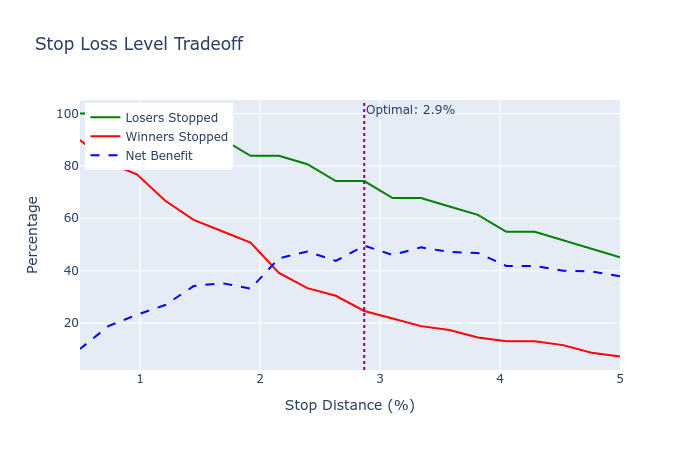

In [30]:
# Mark optimal stop (max net benefit)
optimal_idx = stop_analysis["net_benefit"].idxmax()
optimal_stop = -stop_analysis.loc[optimal_idx, "stop_level"]

fig.add_vline(
    x=optimal_stop,
    line_dash="dot",
    line_color="purple",
    annotation_text=f"Optimal: {optimal_stop:.1f}%",
)

fig.update_layout(
    title="Stop Loss Level Tradeoff",
    xaxis_title="Stop Distance (%)",
    yaxis_title="Percentage",
    height=450,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

In [31]:
print(f"\nOptimal Stop Loss: {optimal_stop:.1f}%")
print("   (Maximizes net benefit of stopping losers vs stopping winners)")


Optimal Stop Loss: 2.9%
   (Maximizes net benefit of stopping losers vs stopping winners)


**Interpretation**: The net-benefit peak is the practical calibration point. It
is not a universal optimum, but it gives a defensible stop level tied to the trade
distribution rather than a round-number heuristic.

### 6.2 Pre-Trade Excursion Percentiles

The trade-level MAE/MFE analysis above is a post-hoc diagnostic on a closed
trade set. The complement is a path-level prior that depends on price history
alone, computed by sliding a fixed-horizon window across the series and
recording the realized minimum and maximum return inside each window.

**Key distinction**:
- **Trade MAE/MFE** (above): per-trade post-hoc analysis on entries, exits, and excursion bounds.
- **Path excursion percentiles** (below): horizon-conditional return-path distribution for pre-trade TP/SL selection.

The summary class packages the percentile matrix so later cells can pull horizon-
specific stop and target suggestions without repeating the table logic.

In [32]:
class ExcursionSummary:
    def __init__(self, percentile_matrix: pd.DataFrame):
        self.percentile_matrix = percentile_matrix

    def summary(self) -> str:
        rows = []
        for horizon in self.percentile_matrix["horizon"].unique():
            subset = self.percentile_matrix[self.percentile_matrix["horizon"] == horizon].set_index(
                "side"
            )
            rows.append(
                {
                    "horizon": horizon,
                    "mae_p25": subset.loc["mae", "p25"],
                    "mfe_p75": subset.loc["mfe", "p75"],
                    "mfe_p90": subset.loc["mfe", "p90"],
                }
            )
        return pd.DataFrame(rows).round(4).to_string(index=False)

    def get_percentile(self, horizon: int, percentile: int, side: str) -> float:
        row = self.percentile_matrix.query("horizon == @horizon and side == @side").iloc[0]
        return float(row[f"p{percentile}"])

The builder scans rolling windows and records the excursion percentiles we use for
pre-trade stop and target calibration.

In [33]:
def build_excursion_summary(prices: np.ndarray, horizons: list[int]) -> ExcursionSummary:
    rows = []
    for horizon in horizons:
        mae_vals = []
        mfe_vals = []
        for start in range(len(prices) - horizon):
            window = prices[start : start + horizon + 1]
            entry_price = window[0]
            rel_path = window / entry_price - 1
            mae_vals.append(rel_path.min())
            mfe_vals.append(rel_path.max())
        for side, values in [("mae", mae_vals), ("mfe", mfe_vals)]:
            rows.append(
                {
                    "horizon": horizon,
                    "side": side,
                    "p10": np.percentile(values, 10),
                    "p25": np.percentile(values, 25),
                    "p50": np.percentile(values, 50),
                    "p75": np.percentile(values, 75),
                    "p90": np.percentile(values, 90),
                }
            )
    return ExcursionSummary(pd.DataFrame(rows))


excursion_result = build_excursion_summary(spy_prices, horizons=[10, 20, 40, 60])
print(excursion_result.summary())

 horizon  mae_p25  mfe_p75  mfe_p90
      10  -0.0286   0.0333   0.0473
      20  -0.0427   0.0486   0.0685
      40  -0.0585   0.0715   0.1025
      60  -0.0736   0.0932   0.1217


**Interpretation**: The percentile table turns raw path data into a calibration
prior. Longer horizons typically widen both favorable and adverse excursions, so
the stop and target should scale with holding period.

In [34]:
# Use the percentile matrix to pick horizon-conditional TP/SL levels
print("\nSuggested TP/SL Levels from Path Excursion Percentiles")
print("=" * 60)

for horizon in [20, 40, 60]:
    tp_75 = excursion_result.get_percentile(horizon=horizon, percentile=75, side="mfe")
    sl_25 = excursion_result.get_percentile(horizon=horizon, percentile=25, side="mae")

    print(f"\nHorizon: {horizon} bars")
    print(f"  Take Profit (75th MFE): {tp_75:+.2%}")
    print(f"  Stop Loss (25th MAE):   {sl_25:+.2%}")


Suggested TP/SL Levels from Path Excursion Percentiles

Horizon: 20 bars
  Take Profit (75th MFE): +4.86%
  Stop Loss (25th MAE):   -4.27%

Horizon: 40 bars
  Take Profit (75th MFE): +7.15%
  Stop Loss (25th MAE):   -5.85%

Horizon: 60 bars
  Take Profit (75th MFE): +9.32%
  Stop Loss (25th MAE):   -7.36%


**Interpretation**: These horizon-level suggestions are useful as starting points,
not fixed rules. They should be compared with the strategy turnover, costs, and
holding-period assumptions before production use.

In [35]:
# Visualize percentile matrix from library
percentile_matrix = excursion_result.percentile_matrix.copy()

mfe_data = percentile_matrix[percentile_matrix["side"] == "mfe"].set_index("horizon")
mae_data = percentile_matrix[percentile_matrix["side"] == "mae"].set_index("horizon")

In [36]:
# Create heatmap-style visualization

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["MFE Percentiles", "MAE Percentiles"],
    horizontal_spacing=0.12,
)

# MFE heatmap
for col in ["p10", "p25", "p50", "p75", "p90"]:
    if col in mfe_data.columns:
        fig.add_trace(
            go.Scatter(
                x=mfe_data.index,
                y=mfe_data[col] * 100,
                name=col.upper(),
                mode="lines+markers",
            ),
            row=1,
            col=1,
        )

# MAE heatmap
for col in ["p10", "p25", "p50", "p75", "p90"]:
    if col in mae_data.columns:
        fig.add_trace(
            go.Scatter(
                x=mae_data.index,
                y=mae_data[col] * 100,
                name=col.upper(),
                mode="lines+markers",
                showlegend=False,
            ),
            row=1,
            col=2,
        )

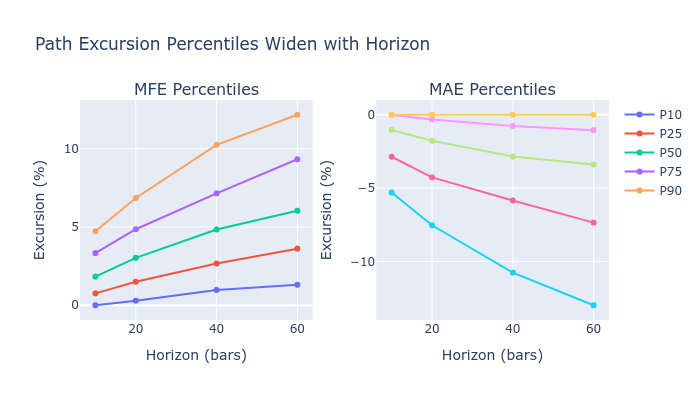

In [37]:
fig.update_xaxes(title_text="Horizon (bars)", row=1, col=1)
fig.update_xaxes(title_text="Horizon (bars)", row=1, col=2)
fig.update_yaxes(title_text="Excursion (%)", row=1, col=1)
fig.update_yaxes(title_text="Excursion (%)", row=1, col=2)

fig.update_layout(
    title="Path Excursion Percentiles Widen with Horizon",
    height=400,
)
fig.show()

**Interpretation**: The percentile curves show whether the trade path expands
symmetrically with horizon. When MAE widens faster than MFE, longer holding periods
demand smaller size or more conservative stops.

**Trade-level vs path-level analysis**:

| Aspect    | Trade MAE/MFE (§6)              | Path excursion percentiles (§6.2)   |
|-----------|---------------------------------|-------------------------------------|
| Purpose   | Post-hoc trade diagnostics      | Pre-trade TP/SL parameter selection |
| Input     | Trade records with entry/exit   | Price series and a horizon          |
| Output    | Per-trade MAE/MFE               | Excursion percentile matrix         |
| Use case  | Why specific trades succeeded   | Setting future TP/SL targets        |

Run the trade-level analysis when reviewing a closed strategy. Run the
path-level analysis when picking horizon-appropriate stop and target levels
before deployment.

## 7. Dynamic Position Sizing Based on Conviction

Adjust position size based on signal strength or conviction score.

In [38]:
def calculate_conviction_based_size(
    base_position_pct: float,
    conviction_score: float,  # 0 to 1
    min_multiplier: float = 0.2,
    max_multiplier: float = 2.0,
) -> float:
    """
    Scale position size by conviction.

    Position = base × (min_multiplier + conviction × (max_multiplier - min_multiplier))
    """
    multiplier = min_multiplier + conviction_score * (max_multiplier - min_multiplier)
    return base_position_pct * multiplier

In [39]:
# Example: Conviction-based sizing
conviction_scores = np.linspace(0, 1, 11)
base_pct = 0.05

conviction_sizing_df = pl.DataFrame(
    {
        "conviction": conviction_scores,
        "position_pct": [calculate_conviction_based_size(base_pct, c) for c in conviction_scores],
    }
)
conviction_sizing_df

conviction,position_pct
f64,f64
0.0,0.01
0.1,0.019
0.2,0.028
0.3,0.037
0.4,0.046
…,…
0.6,0.064
0.7,0.073
0.8,0.082


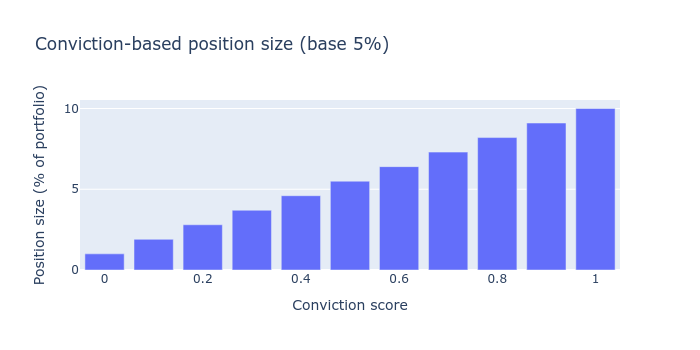

In [40]:
fig = go.Figure(
    go.Bar(
        x=conviction_sizing_df["conviction"],
        y=conviction_sizing_df["position_pct"] * 100,
    )
)
fig.update_layout(
    title=f"Conviction-based position size (base {base_pct:.0%})",
    xaxis_title="Conviction score",
    yaxis_title="Position size (% of portfolio)",
    height=350,
)
fig.show()

**Interpretation**: Conviction-based sizing lets the signal control exposure without
rewriting the stop logic. The main risk is over-scaling weakly calibrated scores.

## 8. Conformal Prediction Intervals and Position Sizing

Conformal prediction (Chapter 11) produces calibrated uncertainty intervals
for return forecasts. Wider intervals indicate higher uncertainty — a natural
signal to reduce position size.

**Concept**: Scale position inversely to conformal interval width:

$$w_t = w_{\text{base}} \times \frac{\Delta_{\text{median}}}{\Delta_t}$$

where $\Delta_t$ is the conformal interval width at time $t$.

See Chapter 17 (`conformal_position_sizing.ipynb`) for a full implementation
that integrates conformal intervals with portfolio construction. The key
risk management insight: conformal intervals provide a model-free uncertainty
estimate that adapts to non-stationarity — exactly the kind of signal risk
managers need for dynamic position sizing.

In [41]:
# Demonstrate the concept with real conformal widths from the ETF case study.
# Each prediction hash under run_log/predictions/ stores a per-(symbol, fold,
# timestamp) split-conformal width parquet; we slice the latest fold's
# cross-section so the demo carries the same dispersion that production sees.
_widths_paths = sorted(
    (get_case_study_dir("etfs") / "run_log" / "predictions").glob("*/conformal_widths.parquet")
)
if not _widths_paths:
    raise FileNotFoundError(
        "No conformal_widths.parquet found in case_studies/etfs/run_log/predictions/. "
        "Run the etfs case study conformal sweep first."
    )

_widths_df = pl.read_parquet(_widths_paths[0])
_latest_fold = _widths_df.filter(pl.col("fold_id") == _widths_df["fold_id"].max())
_latest_ts = _latest_fold["timestamp"].max()
cross_section = _latest_fold.filter(pl.col("timestamp") == _latest_ts).sort("width")

conformal_widths = cross_section["width"].to_numpy()
n_periods = len(conformal_widths)
base_weight = 0.05
median_width = float(np.median(conformal_widths))

adjusted_weights = base_weight * (median_width / conformal_widths)
adjusted_weights = np.clip(adjusted_weights, 0.01, 0.15)

print("Conformal-Adjusted Position Sizing")
print("=" * 55)
print(f"Universe size:         {n_periods} ETFs (cross-section at {_latest_ts.date()})")
print(f"Base weight:           {base_weight:.1%}")
print(f"Median interval width: {median_width:.4f}")
print(f"Adjusted weight range: [{adjusted_weights.min():.1%}, {adjusted_weights.max():.1%}]")
print(f"Mean adjusted weight:  {adjusted_weights.mean():.1%}")
print(f"Tightest band:         {cross_section['symbol'][0]} width={conformal_widths[0]:.4f}")
print(f"Widest band:           {cross_section['symbol'][-1]} width={conformal_widths[-1]:.4f}")

Conformal-Adjusted Position Sizing
Universe size:         88 ETFs (cross-section at 2016-12-23)
Base weight:           5.0%
Median interval width: 0.1901
Adjusted weight range: [2.5%, 9.3%]
Mean adjusted weight:  5.2%
Tightest band:         BIL width=0.1020
Widest band:           UNG width=0.3774


**Interpretation**: Real conformal widths separate the universe along an
uncertainty axis — short-duration fixed-income ETFs sit at the tight end,
single-commodity ETFs at the wide end — and inverse-width sizing rebalances
capital toward the narrow-band names. This is the same signal that drives
the conformal-weighted allocator in `case_studies/etfs/strategy/`.

## 9. Key Takeaways

### Position Sizing Methods

| Method | Best For | Key Parameter |
|--------|----------|---------------|
| **Fixed Fractional** | General use | Risk per trade % |
| **Volatility-Based** | Multi-asset portfolios | Target volatility |
| **Kelly Criterion** | Maximizing growth | Win rate, W/L ratio (Ch17) |
| **Conviction-Based** | Signal-driven strategies | Signal strength |
| **Conformal-Adjusted** | Uncertainty-aware sizing | Interval width (Ch11/Ch17) |

### MAE/MFE Insights

- **MAE reveals optimal stop loss**: Find the level that stops losers without cutting winners
- **MFE reveals missed profits**: How much upside do winning trades typically see?
- **Winners have smaller MAE**: They don't drawdown as much before recovering
- **Losers have high MAE, low MFE**: They drawdown and never recover

### Best Practices

1. **Risk first**: Size positions based on acceptable loss, not profit potential
2. **Adapt to volatility**: Smaller positions in volatile assets/markets
3. **Use fractional Kelly**: Full Kelly is too aggressive; half Kelly is safer
4. **Consider scaling out**: Lock in profits while letting winners run
5. **Analyze your MAE/MFE**: Use your own trade data to optimize stops
6. **Next**: Continue to [`08_ml_exit_signals`](08_ml_exit_signals.ipynb) to connect conviction and exit timing.

---
*Notebook: position_sizing_mae_mfe*
*ML4T 3rd Edition - Chapter 19: Risk Management*